# Challenge 2: Image Classification

## Module imports

In [1]:
import hparams
import image_classifier

import os
import torch
torch.manual_seed(hparams.SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(hparams.SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


PyTorch version: 2.9.1+cpu
Device: cpu


## Image Loader

In [4]:
def load_images_from_folder(folder, cache_path_images, cache_path_masks):

    if os.path.exists(cache_path_images) and os.path.exists(cache_path_masks):
        print(f"Caches found. Loading processed images and masks...")
        images = np.load(cache_path_images)
        masks = np.load(cache_path_masks)
        return images, masks

    print(f"Caches not found. Starting full image/mask loading and preprocessing from '{folder}'...")
    
    image_list = []
    mask_list = []
    
    # Find all unique file IDs 
    ids = set()
    for filename in os.listdir(folder):
        if filename.endswith('.png'):
            parts = filename.split('_')
            if len(parts) == 2 and parts[1].startswith('0') and parts[1].endswith('.png'):
                # Extract the numeric ID (xxxx.png)
                ids.add(parts[1].split('.')[0])
                
    sorted_ids = sorted(list(ids))
    print(f"Found {len(sorted_ids)} unique image/mask pairs based on filenames.")
    
    for image_id in enumerate(sorted_ids):
        image_name = f"img_{image_id}.png"
        mask_name = f"mask_{image_id}.png"
        
        image_path = os.path.join(folder, image_name)
        mask_path = os.path.join(folder, mask_name)
        
        img = cv2.imread(image_path)
        img = (img / 255.0).astype(np.float32)
        img = img[..., ::-1]
        
        h, w = img.shape[:2]
        if h > w:
            delta_w = h - w
            top, bottom = 0, 0
            left = delta_w // 2
            right = delta_w - left
        elif w > h:
            delta_h = w - h
            left, right = 0, 0
            top = delta_h // 2
            bottom = delta_h - top
        else:
            top, bottom, left, right = 0, 0, 0, 0

        image = cv2.copyMakeBorder(
            img, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[0, 0, 0]
        )

        image = cv2.resize(image, (hparams.IMAGE_SIZE, hparams.IMAGE_SIZE))
        image_list.append(image)
        img = cv2.imread(mask_path)

        img = (img / 255.0).astype(np.float32)
        img = img[..., ::-1]
        
        h, w = img.shape[:2]
        if h > w:
            delta_w = h - w
            top, bottom = 0, 0
            left = delta_w // 2
            right = delta_w - left
        elif w > h:
            delta_h = w - h
            left, right = 0, 0
            top = delta_h // 2
            bottom = delta_h - top
        else:
            top, bottom, left, right = 0, 0, 0, 0

        mask = cv2.copyMakeBorder(
            img, top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[0, 0, 0]
        )

        mask = cv2.resize(mask, (hparams.IMAGE_SIZE, hparams.IMAGE_SIZE))
        mask_list.append(mask)

    final_images = np.array(image_list)
    final_masks = np.array(mask_list)

    cache_dir = os.path.dirname(cache_path_images)
    if cache_dir and not os.path.exists(cache_dir):
        os.makedirs(cache_dir, exist_ok=True)
        print(f"Created cache directory: {cache_dir}")
    
    print(f"Finished preprocessing {len(final_images)} pairs. Saving to caches...")
    np.save(cache_path_images, final_images)
    np.save(cache_path_masks, final_masks)
    
    return final_images, final_masks

train_images, train_masks = load_images_from_folder(hparams.TRAIN_DATA_PATH, hparams.TRAIN_IMAGES_CACHE_PATH, hparams.TRAIN_MASKS_CACHE_PATH)
print(f"Loaded {len(train_images)} images for training")


Caches found. Loading processed images and masks...
Loaded 1000 images for training


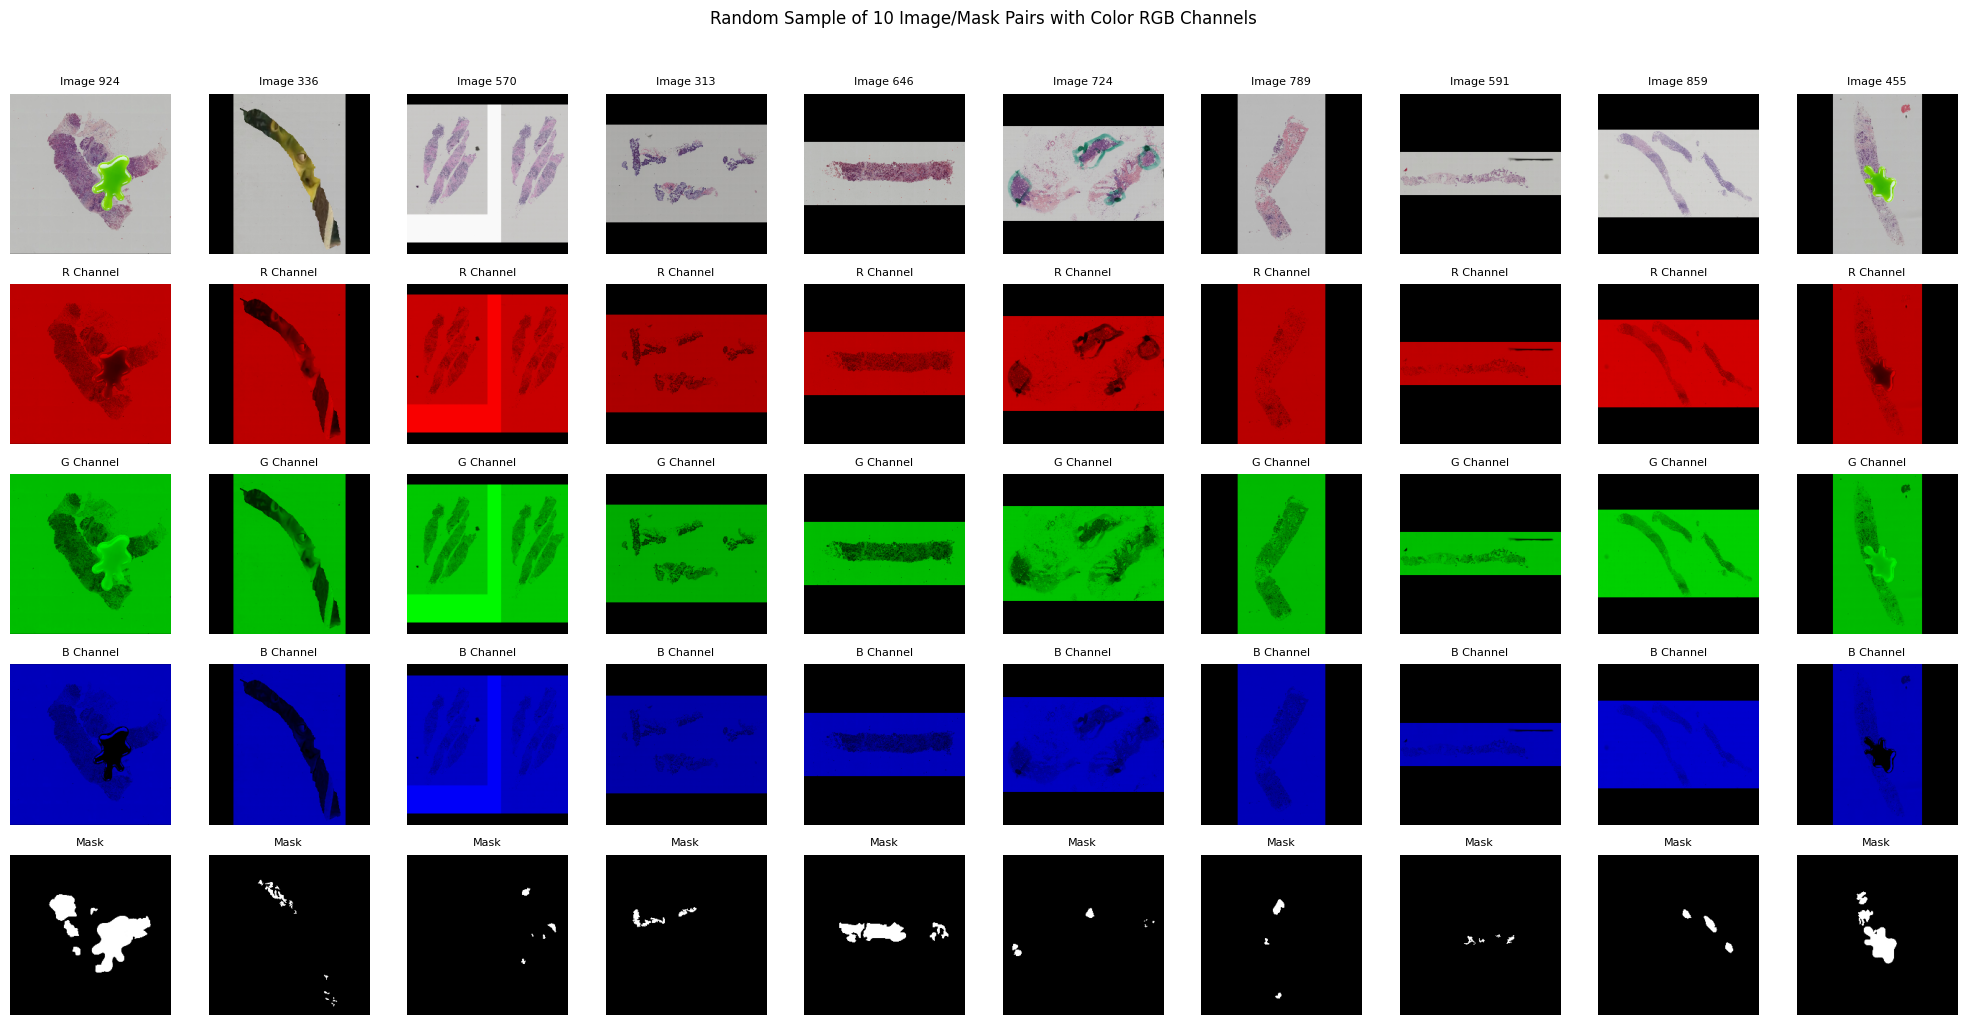

In [ ]:
# Number of images to display
num_samples = 10 
random_indices = np.random.choice(len(train_images), size=num_samples, replace=False)

# 5 rows: Image, R, G, B, Mask
fig, axes = plt.subplots(5, num_samples, figsize=(20, 10))

for i, idx in enumerate(random_indices):
    # Clip image and mask data once for plotting
    img = np.clip(train_images[idx], 0, 1)
    mask = np.clip(train_masks[idx], 0, 1)
    
    # Create 3-channel visualizations for R, G, B
    
    # Red Channel Visualization
    color_r = np.zeros_like(img)
    color_r[..., 0] = img[..., 0]
    
    # Green Channel Visualization
    color_g = np.zeros_like(img)
    color_g[..., 1] = img[..., 1]
    
    # Blue Channel Visualization
    color_b = np.zeros_like(img)
    color_b[..., 2] = img[..., 2]

    # Row 0: Image (RGB)
    ax_img = axes[0, i]
    ax_img.imshow(img) 
    ax_img.set_title(f"Image {idx}", fontsize=8)
    ax_img.axis('off')

    # Row 1: Red Channel (Color representation)
    ax_r = axes[1, i]
    ax_r.imshow(color_r)
    ax_r.set_title("R Channel", fontsize=8)
    ax_r.axis('off')

    # Row 2: Green Channel (Color representation)
    ax_g = axes[2, i]
    ax_g.imshow(color_g)
    ax_g.set_title("G Channel", fontsize=8)
    ax_g.axis('off')

    # Row 3: Blue Channel (Color representation)
    ax_b = axes[3, i]
    ax_b.imshow(color_b)
    ax_b.set_title("B Channel", fontsize=8)
    ax_b.axis('off')

    # Row 4: Corresponding Mask
    ax_mask = axes[4, i]
    ax_mask.imshow(mask)
    ax_mask.set_title("Mask", fontsize=8)
    ax_mask.axis('off')

plt.suptitle(f"Random Sample of {num_samples} Image/Mask Pairs with Color RGB Channels", y=1.02)
plt.tight_layout()
plt.show()